# Heatmap benchmark plots

Reads the latest `logs/heatmap_qubo_*.json` produced by
`heatmap_benchmark_segment2.py` and renders two figures, one subplot per
edge-probability `p`:

1. **Mean first-optimal-hit** — averaged over the seeds that actually
   found the optimum within the read budget. Cells where no seed solved
   show as `—` (NaN).
2. **Success rate** — fraction of seeds (out of `NUM_INSTANCES_PER_COMBO`)
   whose `10 × 100 = 1000` reads contained at least one optimal solution.

In [9]:
import glob
import json
import os

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Point this at a specific file (absolute or relative path) to override.
# version 6 or 7 idk
#500
#QUBO_JSON_PATH = "/Users/daghanerdonmez/Desktop/logs/heatmap_qubo_20260418_085054.json"  # None -> load the most recent heatmap_qubo_*.json in ./logs
#200
#QUBO_JSON_PATH = "/Users/daghanerdonmez/Desktop/logs/heatmap_qubo_20260418_085007.json"  # None -> load the most recent heatmap_qubo_*.json in ./logs
#100
#QUBO_JSON_PATH = "/Users/daghanerdonmez/Desktop/evvifing/boun/cmpe/491-492/finale/SteinerTreeProblemQUBO/logs/heatmap_qubo_merged.json"

# version 8

LOGS_DIR = "logs"


def load_qubo_results(path=None, directory=LOGS_DIR):
    if path is None:
        files = sorted(glob.glob(os.path.join(directory, "heatmap_qubo_*.json")))
        if not files:
            raise FileNotFoundError(
                f"No heatmap_qubo_*.json in {directory}. Run segment 2 first."
            )
        path = files[-1]
    with open(path) as f:
        return json.load(f), path


data, data_path = load_qubo_results(QUBO_JSON_PATH)
meta = data["_meta"]
summary = data["summary"]

print(f"loaded:   {data_path}")
print(f"p values: {meta['edge_probability_list']}")
print(f"n values: {meta['node_count_list']}")
print(f"k values: {meta['terminal_count_list']}")
print(
    f"budget:   {meta['total_reads_per_instance']} reads/instance "
    f"({meta['num_trials']} x {meta['num_reads_per_trial']}), "
    f"{meta['num_instances_per_combo']} seeds/combo"
)

loaded:   /Users/daghanerdonmez/Desktop/evvifing/boun/cmpe/491-492/finale/SteinerTreeProblemQUBO/logs/heatmap_qubo_merged.json
p values: [0.1, 0.3, 0.6]
n values: [4, 6, 8, 10, 12]
k values: [2, 3, 4, 5, 6]
budget:   1000 reads/instance (10 x 100), 10 seeds/combo


In [38]:
p_list = meta["edge_probability_list"]
n_list = meta["node_count_list"]
k_list = meta["terminal_count_list"]

# shape (p, k, n) — k is y-axis, n is x-axis (matches imshow row/col)
mean_first_hit = np.full((len(p_list), len(k_list), len(n_list)), np.nan)
success_rate = np.full((len(p_list), len(k_list), len(n_list)), np.nan)

for pi, p in enumerate(p_list):
    for ki, k in enumerate(k_list):
        for ni, n in enumerate(n_list):
            if k > n:
                continue  # infeasible combo -> leave NaN
            key = f"p={p}|n={n}|k={k}"
            entry = summary.get(key)
            if entry is None:
                continue
            if entry.get("success_rate") is not None:
                success_rate[pi, ki, ni] = entry["success_rate"]
            avg_hit = entry.get("avg_first_hit_reads_when_solved")
            if avg_hit is not None:
                mean_first_hit[pi, ki, ni] = avg_hit

print("mean_first_hit shape:", mean_first_hit.shape)
print("success_rate   shape:", success_rate.shape)

mean_first_hit shape: (3, 5, 5)
success_rate   shape: (3, 5, 5)


In [39]:
def plot_heatmaps(arr, p_list, n_list, k_list, *, title,
                  cbar_label, fmt, cmap, vmin, vmax, missing_glyph="\u2014"):
    """Render one heatmap subplot per p, with NaN cells shown as `missing_glyph`."""
    fig, axes = plt.subplots(
        1, len(p_list), figsize=(4.8 * len(p_list), 4.5), squeeze=False
    )
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="#dddddd")  # NaN color

    for ax, pi in zip(axes[0], range(len(p_list))):
        masked = np.ma.masked_invalid(arr[pi])
        im = ax.imshow(masked, origin="lower", aspect="auto",
                       cmap=cmap_obj, vmin=vmin, vmax=vmax)
        ax.set_xticks(range(len(n_list)), [str(n) for n in n_list])
        ax.set_yticks(range(len(k_list)), [str(k) for k in k_list])
        ax.set_xlabel("number of nodes (n)")
        ax.set_ylabel("number of terminals (k)")
        ax.set_title(f"p = {p_list[pi]}")

        mid = 0.5 * (vmin + vmax)
        for ki in range(len(k_list)):
            for ni in range(len(n_list)):
                v = arr[pi, ki, ni]
                if np.isnan(v):
                    txt = missing_glyph
                    color = "#555555"
                else:
                    txt = fmt.format(v)
                    color = "white" if v < mid else "black"
                ax.text(ni, ki, txt, ha="center", va="center",
                        color=color, fontsize=9)
        plt.colorbar(im, ax=ax, label=cbar_label)

    fig.suptitle(title)
    fig.tight_layout()
    return fig

constraint_weight = 500

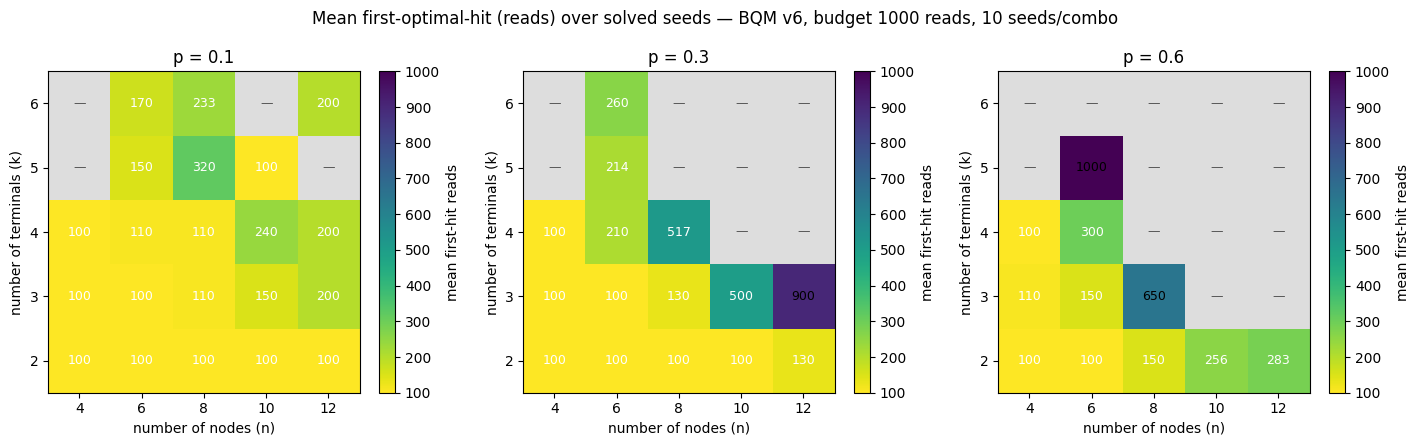

In [17]:
budget = meta["total_reads_per_instance"]
reads_per_trial = meta["num_reads_per_trial"]

# viridis_r so that fewer reads (faster) = brighter/yellow, more reads = darker.
fig1 = plot_heatmaps(
    mean_first_hit, p_list, n_list, k_list,
    title=(
        f"Mean first-optimal-hit (reads) over solved seeds — "
        f"BQM v{meta['bqm_version']}, budget {budget} reads, "
        f"{meta['num_instances_per_combo']} seeds/combo"
    ),
    cbar_label="mean first-hit reads",
    fmt="{:.0f}",
    cmap="viridis_r",
    vmin=reads_per_trial,
    vmax=budget,
)
plt.show()

constraint_weight = 200

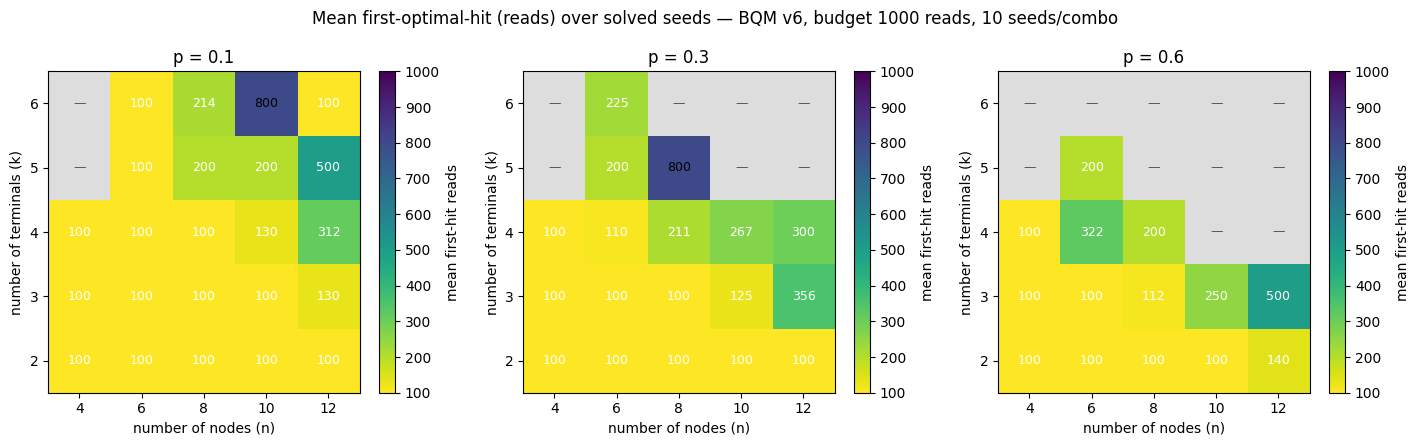

In [12]:
budget = meta["total_reads_per_instance"]
reads_per_trial = meta["num_reads_per_trial"]

# viridis_r so that fewer reads (faster) = brighter/yellow, more reads = darker.
fig1 = plot_heatmaps(
    mean_first_hit, p_list, n_list, k_list,
    title=(
        f"Mean first-optimal-hit (reads) over solved seeds — "
        f"BQM v{meta['bqm_version']}, budget {budget} reads, "
        f"{meta['num_instances_per_combo']} seeds/combo"
    ),
    cbar_label="mean first-hit reads",
    fmt="{:.0f}",
    cmap="viridis_r",
    vmin=reads_per_trial,
    vmax=budget,
)
plt.show()

constraint_weight = 100

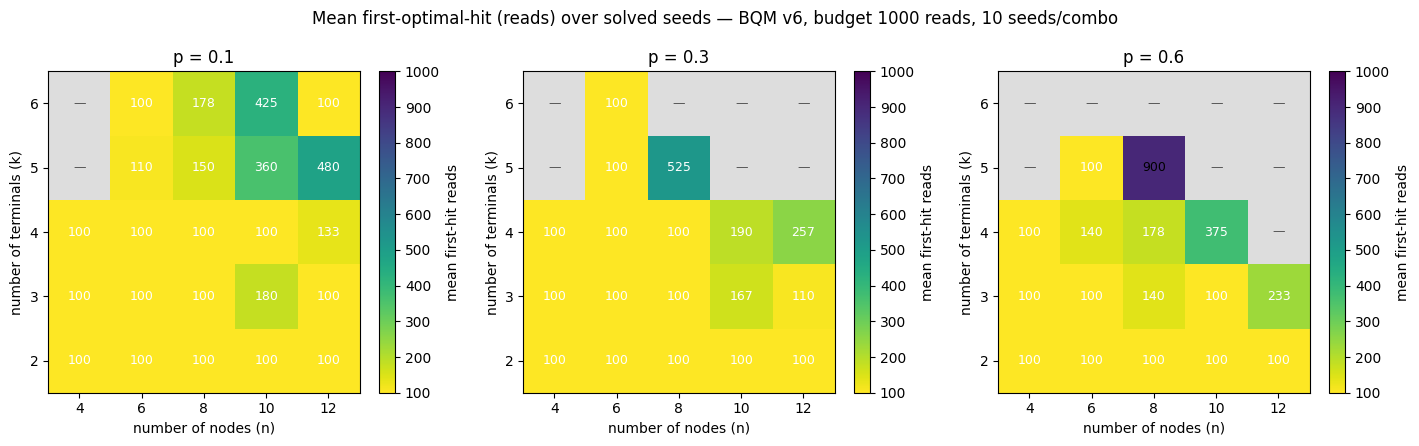

In [40]:
budget = meta["total_reads_per_instance"]
reads_per_trial = meta["num_reads_per_trial"]

# viridis_r so that fewer reads (faster) = brighter/yellow, more reads = darker.
fig1 = plot_heatmaps(
    mean_first_hit, p_list, n_list, k_list,
    title=(
        f"Mean first-optimal-hit (reads) over solved seeds — "
        f"BQM v{meta['bqm_version']}, budget {budget} reads, "
        f"{meta['num_instances_per_combo']} seeds/combo"
    ),
    cbar_label="mean first-hit reads",
    fmt="{:.0f}",
    cmap="viridis_r",
    vmin=reads_per_trial,
    vmax=budget,
)
plt.show()

constraint_weight = 500

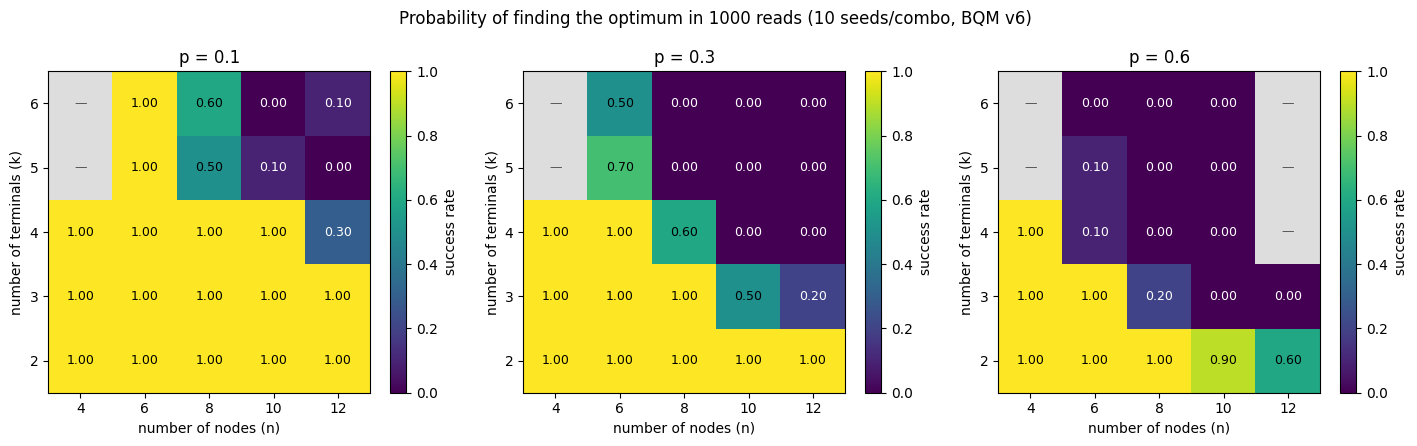

In [18]:
fig2 = plot_heatmaps(
    success_rate, p_list, n_list, k_list,
    title=(
        f"Probability of finding the optimum in {budget} reads "
        f"({meta['num_instances_per_combo']} seeds/combo, BQM v{meta['bqm_version']})"
    ),
    cbar_label="success rate",
    fmt="{:.2f}",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)
plt.show()

constraint_weight = 200

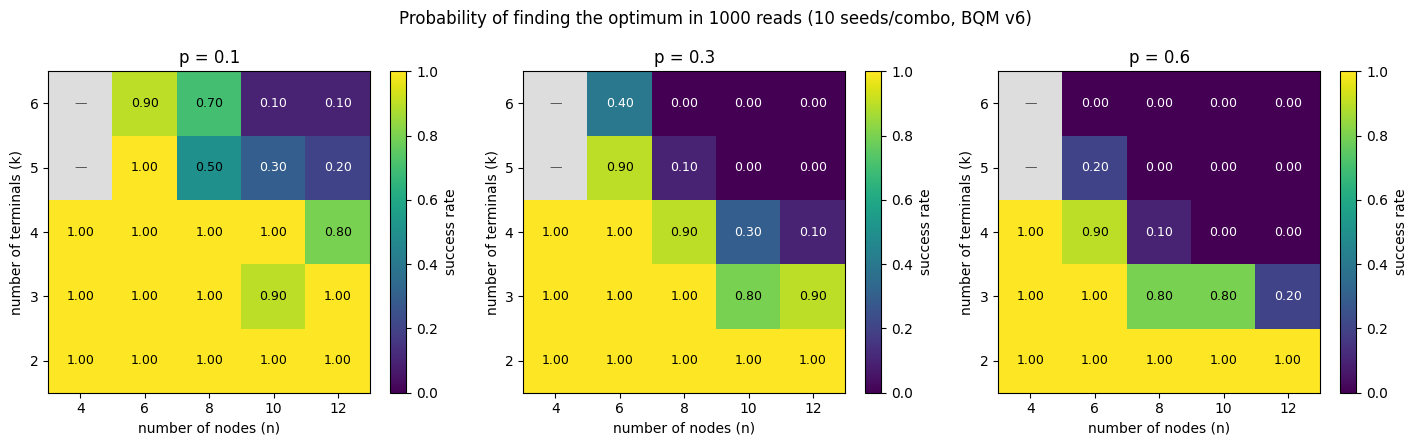

In [13]:
fig2 = plot_heatmaps(
    success_rate, p_list, n_list, k_list,
    title=(
        f"Probability of finding the optimum in {budget} reads "
        f"({meta['num_instances_per_combo']} seeds/combo, BQM v{meta['bqm_version']})"
    ),
    cbar_label="success rate",
    fmt="{:.2f}",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)
plt.show()

constraint_weight = 100

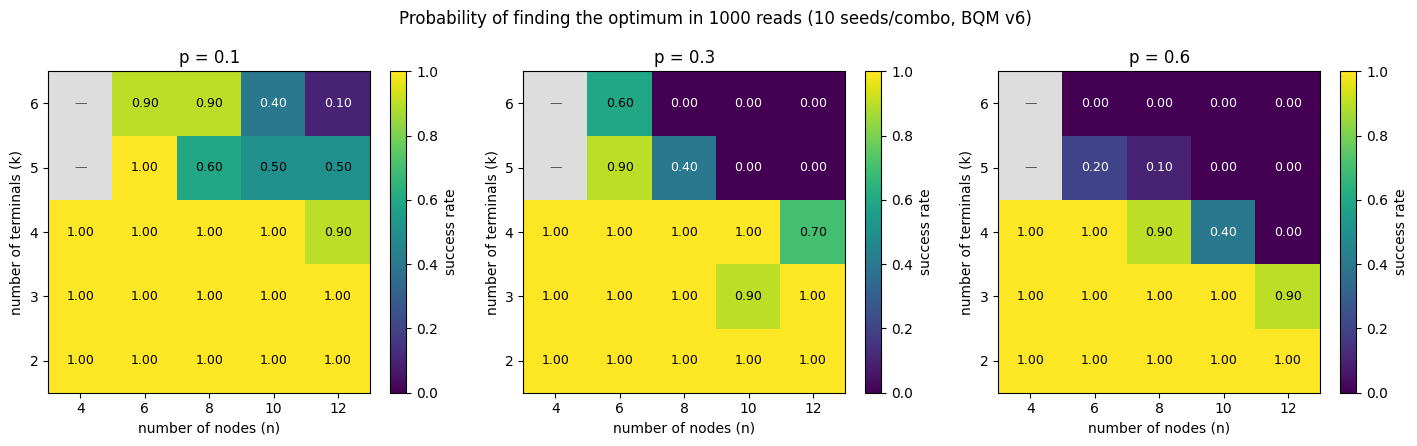

In [41]:
fig2 = plot_heatmaps(
    success_rate, p_list, n_list, k_list,
    title=(
        f"Probability of finding the optimum in {budget} reads "
        f"({meta['num_instances_per_combo']} seeds/combo, BQM v{meta['bqm_version']})"
    ),
    cbar_label="success rate",
    fmt="{:.2f}",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)
plt.show()

constraint_weight = 500

In [34]:
instances = data.get("instances", {})

# Per-combo mean approximation ratio = mean over valid seeds of (best_qubo_cost / ilp_cost).
# "Valid" = not flagged as discarded / buggy_below_optimal.  Instances that never
# hit the optimum still contribute — their ratio is just > 1.0 — so this metric
# captures solution quality even when success_rate = 0.
_sum = np.zeros((len(p_list), len(k_list), len(n_list)))
_cnt = np.zeros_like(_sum, dtype=int)

for inst in instances.values():
    if inst.get("discarded") or inst.get("buggy_below_optimal"):
        continue
    p_ = inst.get("edge_probability")
    n_ = inst.get("node_count")
    k_ = inst.get("terminal_count")
    opt = inst.get("ilp_cost")
    best = inst.get("best_cost")
    if p_ not in p_list or n_ not in n_list or k_ not in k_list:
        continue
    if opt is None or best is None or opt <= 0:
        continue
    pi = p_list.index(p_)
    ki = k_list.index(k_)
    ni = n_list.index(n_)
    _sum[pi, ki, ni] += best / opt
    _cnt[pi, ki, ni] += 1

mean_ratio = np.full_like(_sum, np.nan)
mask = _cnt > 0
mean_ratio[mask] = _sum[mask] / _cnt[mask]

finite = mean_ratio[np.isfinite(mean_ratio)]
print(f"mean_ratio shape: {mean_ratio.shape}")
if finite.size:
    print(
        f"min={finite.min():.3f}  max={finite.max():.3f}  "
        f"cells with data: {finite.size}"
    )
else:
    print("no valid instances found — check that the JSON has instances with best_cost and ilp_cost")

mean_ratio shape: (3, 5, 5)
min=1.000  max=23.954  cells with data: 69


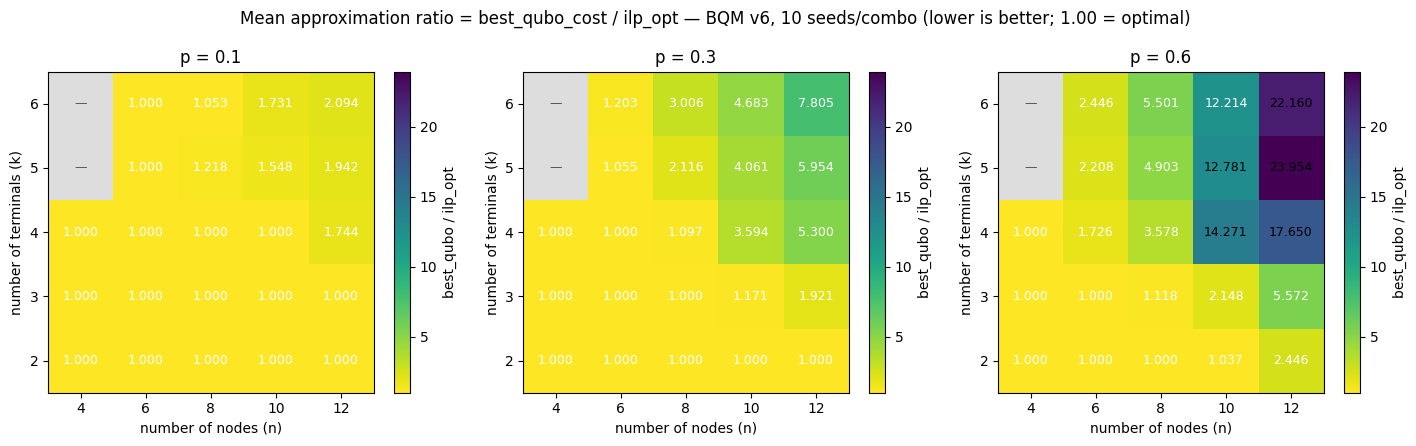

In [36]:
# Approximation ratio heatmap.  1.00 = matched the ILP optimum on average,
# > 1 = worse.  vmax is data-driven but floored at 1.05 so that near-perfect
# combos still show some colour variation.
if finite.size:
    vmax_ratio = max(1.05, float(np.nanmax(mean_ratio)))
else:
    vmax_ratio = 1.05

fig3 = plot_heatmaps(
    mean_ratio, p_list, n_list, k_list,
    title=(
        f"Mean approximation ratio = best_qubo_cost / ilp_opt — "
        f"BQM v{meta['bqm_version']}, {meta['num_instances_per_combo']} seeds/combo "
        f"(lower is better; 1.00 = optimal)"
    ),
    cbar_label="best_qubo / ilp_opt",
    fmt="{:.3f}",
    cmap="viridis_r",
    vmin=1.0,
    vmax=vmax_ratio,
)
plt.show()

constraint_weight = 200

In [29]:
instances = data.get("instances", {})

# Per-combo mean approximation ratio = mean over valid seeds of (best_qubo_cost / ilp_cost).
# "Valid" = not flagged as discarded / buggy_below_optimal.  Instances that never
# hit the optimum still contribute — their ratio is just > 1.0 — so this metric
# captures solution quality even when success_rate = 0.
_sum = np.zeros((len(p_list), len(k_list), len(n_list)))
_cnt = np.zeros_like(_sum, dtype=int)

for inst in instances.values():
    if inst.get("discarded") or inst.get("buggy_below_optimal"):
        continue
    p_ = inst.get("edge_probability")
    n_ = inst.get("node_count")
    k_ = inst.get("terminal_count")
    opt = inst.get("ilp_cost")
    best = inst.get("best_cost")
    if p_ not in p_list or n_ not in n_list or k_ not in k_list:
        continue
    if opt is None or best is None or opt <= 0:
        continue
    pi = p_list.index(p_)
    ki = k_list.index(k_)
    ni = n_list.index(n_)
    _sum[pi, ki, ni] += best / opt
    _cnt[pi, ki, ni] += 1

mean_ratio = np.full_like(_sum, np.nan)
mask = _cnt > 0
mean_ratio[mask] = _sum[mask] / _cnt[mask]

finite = mean_ratio[np.isfinite(mean_ratio)]
print(f"mean_ratio shape: {mean_ratio.shape}")
if finite.size:
    print(
        f"min={finite.min():.3f}  max={finite.max():.3f}  "
        f"cells with data: {finite.size}"
    )
else:
    print("no valid instances found — check that the JSON has instances with best_cost and ilp_cost")

mean_ratio shape: (3, 5, 5)
min=1.000  max=20.083  cells with data: 69


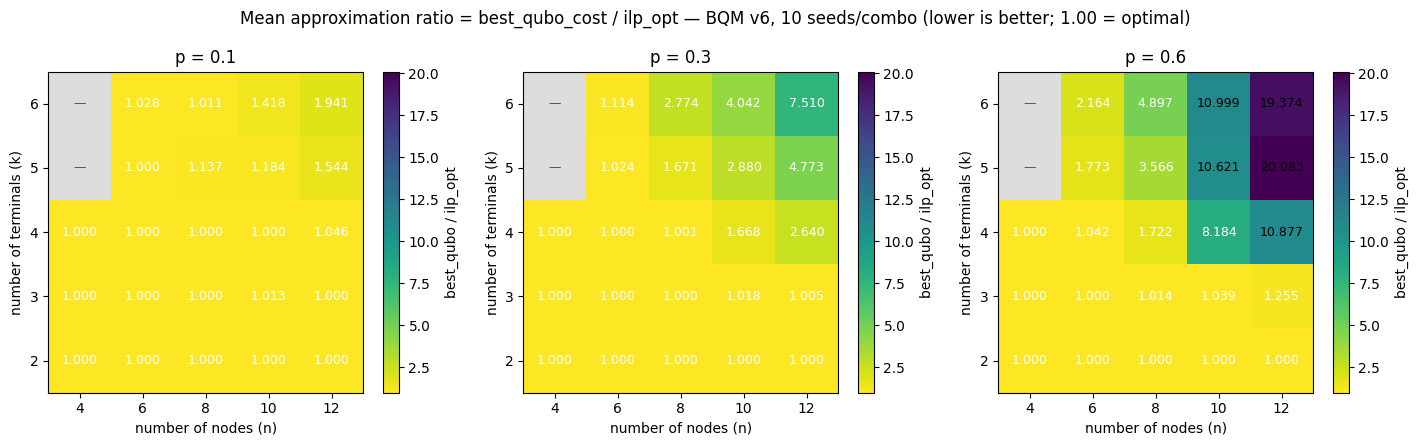

In [30]:
# Approximation ratio heatmap.  1.00 = matched the ILP optimum on average,
# > 1 = worse.  vmax is data-driven but floored at 1.05 so that near-perfect
# combos still show some colour variation.
if finite.size:
    vmax_ratio = max(1.05, float(np.nanmax(mean_ratio)))
else:
    vmax_ratio = 1.05

fig3 = plot_heatmaps(
    mean_ratio, p_list, n_list, k_list,
    title=(
        f"Mean approximation ratio = best_qubo_cost / ilp_opt — "
        f"BQM v{meta['bqm_version']}, {meta['num_instances_per_combo']} seeds/combo "
        f"(lower is better; 1.00 = optimal)"
    ),
    cbar_label="best_qubo / ilp_opt",
    fmt="{:.3f}",
    cmap="viridis_r",
    vmin=1.0,
    vmax=vmax_ratio,
)
plt.show()

constraint_weight = 100

In [42]:
instances = data.get("instances", {})

# Per-combo mean approximation ratio = mean over valid seeds of (best_qubo_cost / ilp_cost).
# "Valid" = not flagged as discarded / buggy_below_optimal.  Instances that never
# hit the optimum still contribute — their ratio is just > 1.0 — so this metric
# captures solution quality even when success_rate = 0.
_sum = np.zeros((len(p_list), len(k_list), len(n_list)))
_cnt = np.zeros_like(_sum, dtype=int)

for inst in instances.values():
    if inst.get("discarded") or inst.get("buggy_below_optimal"):
        continue
    p_ = inst.get("edge_probability")
    n_ = inst.get("node_count")
    k_ = inst.get("terminal_count")
    opt = inst.get("ilp_cost")
    best = inst.get("best_cost")
    if p_ not in p_list or n_ not in n_list or k_ not in k_list:
        continue
    if opt is None or best is None or opt <= 0:
        continue
    pi = p_list.index(p_)
    ki = k_list.index(k_)
    ni = n_list.index(n_)
    _sum[pi, ki, ni] += best / opt
    _cnt[pi, ki, ni] += 1

mean_ratio = np.full_like(_sum, np.nan)
mask = _cnt > 0
mean_ratio[mask] = _sum[mask] / _cnt[mask]

finite = mean_ratio[np.isfinite(mean_ratio)]
print(f"mean_ratio shape: {mean_ratio.shape}")
if finite.size:
    print(
        f"min={finite.min():.3f}  max={finite.max():.3f}  "
        f"cells with data: {finite.size}"
    )
else:
    print("no valid instances found — check that the JSON has instances with best_cost and ilp_cost")

mean_ratio shape: (3, 5, 5)
min=1.000  max=16.397  cells with data: 69


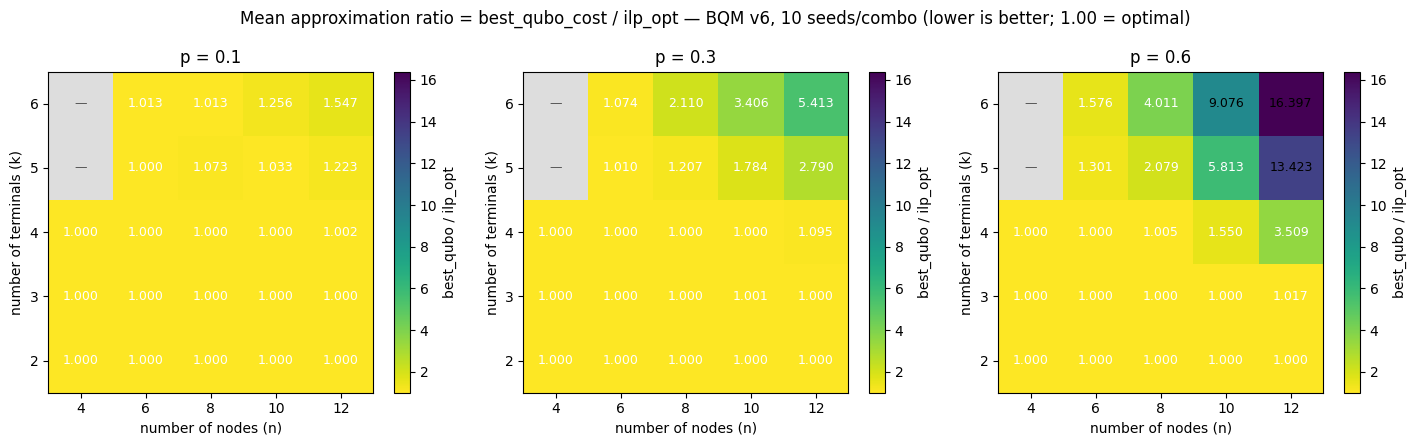

In [43]:
# Approximation ratio heatmap.  1.00 = matched the ILP optimum on average,
# > 1 = worse.  vmax is data-driven but floored at 1.05 so that near-perfect
# combos still show some colour variation.
if finite.size:
    vmax_ratio = max(1.05, float(np.nanmax(mean_ratio)))
else:
    vmax_ratio = 1.05

fig3 = plot_heatmaps(
    mean_ratio, p_list, n_list, k_list,
    title=(
        f"Mean approximation ratio = best_qubo_cost / ilp_opt — "
        f"BQM v{meta['bqm_version']}, {meta['num_instances_per_combo']} seeds/combo "
        f"(lower is better; 1.00 = optimal)"
    ),
    cbar_label="best_qubo / ilp_opt",
    fmt="{:.3f}",
    cmap="viridis_r",
    vmin=1.0,
    vmax=vmax_ratio,
)
plt.show()